In [2]:
import pandas as pd

url = 'https://drive.google.com/uc?export=download&id=1AoWtGUSumBXfHTYjyB3mnVqmR-5SV2N0'
df = pd.read_csv(url, encoding='latin-1')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.describe()

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


In [6]:
import sqlite3

conn = sqlite3.connect('ecommerce.db')

In [7]:
df.to_sql('online_retail', conn, if_exists='replace', index=False)

clean_df = pd.read_sql("""
SELECT *
FROM online_retail
WHERE Quantity > 0
  AND Price > 0
  AND "Customer ID" IS NOT NULL
""", conn)

clean_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
clean_df.describe()

,Quantity,Price,Customer ID
count,397885.000000,397885.000000,397885.000000
mean,12.988208,3.116525,15294.416882
std,179.331551,22.097861,1713.144421
min,1.000000,0.001000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [9]:
clean_df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [10]:
print("Before cleaning:", len(df))
print("After cleaning:", len(clean_df))

Before cleaning: 541910
After cleaning: 397885


In [11]:
clean_df['InvoiceDate'] = pd.to_datetime(clean_df['InvoiceDate'], format='%m/%d/%Y %H:%M')
clean_df.to_sql('online_retail_clean', conn, if_exists='replace', index=False)

397885

#Step 4
RFM FEATURE ENGINEERING (USING SQL)

In [12]:
rfm = pd.read_sql("""
SELECT
    "Customer ID" AS CustomerID,

    -- Recency (days since last purchase)
    CAST(
        JULIANDAY((SELECT MAX(InvoiceDate) FROM online_retail_clean))
        - JULIANDAY(MAX(InvoiceDate))
    AS INTEGER) AS Recency,

    -- Frequency (number of unique purchases)
    COUNT(DISTINCT Invoice) AS Frequency,

    -- Monetary (total money spent)
    SUM(Quantity * Price) AS Monetary

FROM online_retail_clean

GROUP BY "Customer ID"
""", conn)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


# Step 5: RFM Scoring (1–5 scores per customer)

In [13]:
rfm['R_score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [14]:
rfm[['R_score','F_score','M_score']].head()

,R_score,F_score,M_score
0,1,1,5
1,5,5,5
2,2,4,4
3,4,1,4
4,1,1,2


In [15]:
rfm[['R_score','F_score','M_score']].describe()

,R_score,F_score,M_score
count,4338,4338,4338
unique,5,5,5
top,5,1,1
freq,868,868,868


#Step: 6 - KMEANS CLUSTERING

In [16]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

In [17]:
import numpy as np

features_log = np.log1p(features)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_log)

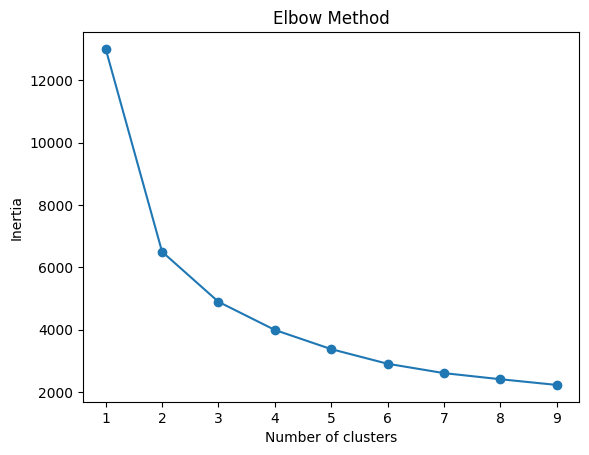

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [20]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(features_scaled)

In [21]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Cluster
0,12346.0,325,1,77183.60,1,1,5,3
1,12347.0,1,7,4310.00,5,5,5,1
2,12348.0,74,4,1797.24,2,4,4,3
3,12349.0,18,1,1757.55,4,1,4,0
4,12350.0,309,1,334.40,1,1,2,2


In [22]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,16.726131,2.119347,544.994510
1,10.659091,13.805398,8142.817287
2,179.601966,1.313268,341.935590
3,69.318182,4.122314,1808.591540


In [23]:
def label_cluster(row):
    if row['Cluster'] == 0:
        return 'VIP'
    elif row['Cluster'] == 1:
        return 'Churn Risk'
    elif row['Cluster'] == 2:
        return 'Regular'
    else:
        return 'Low Value'

rfm['Segment'] = rfm.apply(label_cluster, axis=1)

# STEP 7: VISUALIZATIONS

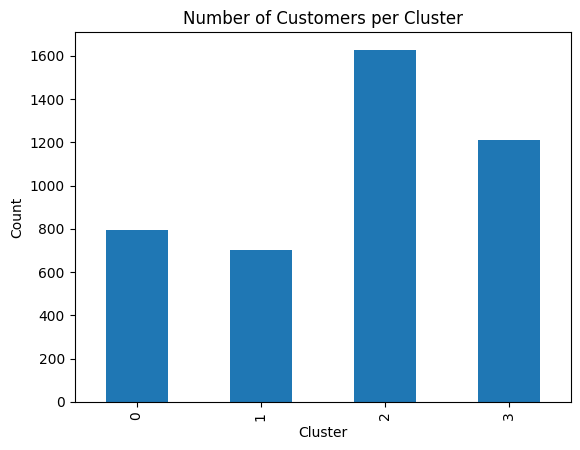

In [24]:
import matplotlib.pyplot as plt

rfm['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

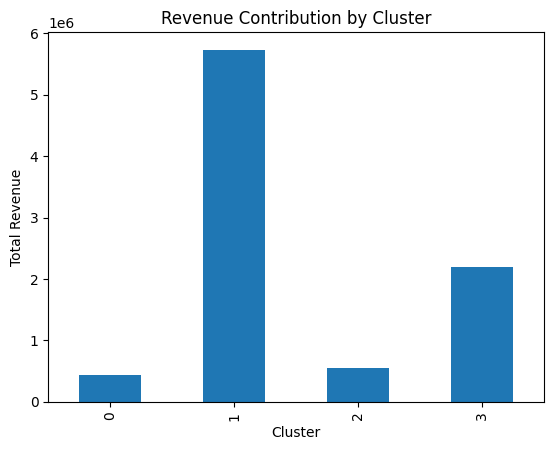

In [25]:
rfm.groupby('Cluster')['Monetary'].sum().plot(kind='bar')
plt.title('Revenue Contribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Total Revenue')
plt.show()

In [26]:
rfm['Segment'] = rfm['Cluster'].map({
    0: 'VIP',
    1: 'Churn Risk',
    2: 'Regular',
    3: 'Low Value'
})

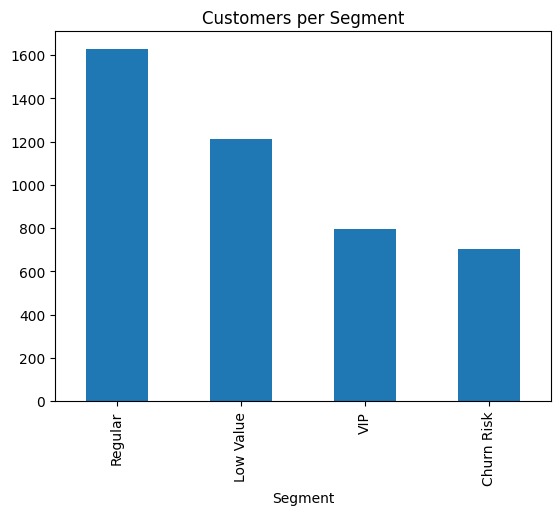

In [27]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title('Customers per Segment')
plt.show()

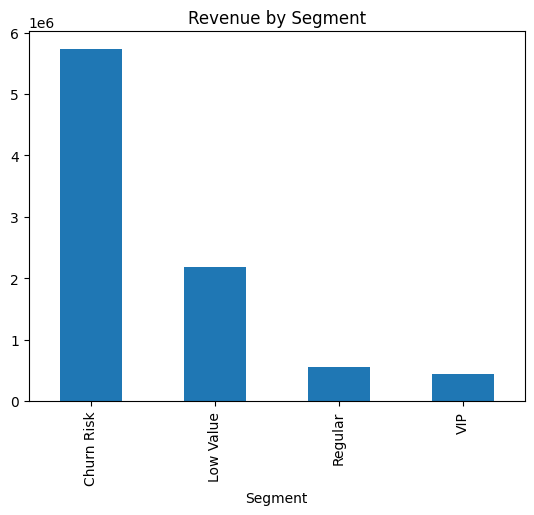

In [28]:
rfm.groupby('Segment')['Monetary'].sum().plot(kind='bar')
plt.title('Revenue by Segment')
plt.show()

#STEP 8: INTERPRETING CLUSTERS

In [29]:
def label_cluster(row):
    if row['Cluster'] == 2:
        return 'Champions'    # best: recent, frequent, high spend
    elif row['Cluster'] == 0:
        return 'Loyal'        # good: mid recency, some frequency
    elif row['Cluster'] == 1:
        return 'Churn Risk'   # recent but barely buying
    else:
        return 'Lost'         # old, infrequent, low spend

rfm['Segment'] = rfm.apply(label_cluster, axis=1)

In [30]:
!pip install plotly -q

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

In [31]:
# Color map matching your segment names
color_map = {
    'Champions' : '#1D9E75',   # green  → best customers
    'Loyal'     : '#185FA5',   # blue   → good customers
    'Churn Risk': '#EF9F27',   # amber  → warning
    'Lost'      : '#E24B4A',   # red    → gone
}

fig_3d = px.scatter_3d(
    rfm,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Segment',
    color_discrete_map=color_map,
    opacity=0.75,
    title='Customer Segments — RFM 3D View',
    labels={
        'Recency'  : 'Recency (days since last purchase)',
        'Frequency': 'Frequency (no. of orders)',
        'Monetary' : 'Monetary (total £ spent)'
    }
)

fig_3d.update_traces(marker=dict(size=3))
fig_3d.update_layout(
    legend_title_text='Segment',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig_3d.show()

In [32]:
rev = rfm.groupby('Segment')['Monetary'].sum().reset_index()
rev.columns = ['Segment', 'Total Revenue']

fig_pie = px.pie(
    rev,
    names='Segment',
    values='Total Revenue',
    title='Revenue Share by Customer Segment',
    color='Segment',
    color_discrete_map=color_map,
    hole=0.4   # donut style
)

fig_pie.update_traces(
    textinfo='label+percent',
    textfont_size=13,
    pull=[0.05, 0, 0, 0]   # slightly pull out the first slice
)

fig_pie.update_layout(
    legend_title_text='Segment',
    annotations=[dict(text='Revenue', x=0.5, y=0.5, font_size=14, showarrow=False)]
)

fig_pie.show()

In [33]:
from sklearn.preprocessing import MinMaxScaler

# Get mean RFM per segment
radar_data = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

# Normalise to 0–1 scale, then INVERT Recency (lower days = better)
mms = MinMaxScaler()
radar_norm = pd.DataFrame(
    mms.fit_transform(radar_data),
    index=radar_data.index,
    columns=radar_data.columns
)
radar_norm['Recency'] = 1 - radar_norm['Recency']  # invert so higher = better

categories = ['Recency', 'Frequency', 'Monetary']

fig_radar = go.Figure()

for segment in radar_norm.index:
    vals = radar_norm.loc[segment, categories].tolist()
    vals += [vals[0]]  # close the polygon

    fig_radar.add_trace(go.Scatterpolar(
        r=vals,
        theta=categories + [categories[0]],
        fill='toself',
        name=segment,
        line_color=color_map.get(segment, 'grey'),
        opacity=0.7
    ))

fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickvals=[0.25, 0.5, 0.75, 1.0],
            ticktext=['Low', 'Mid', 'High', 'Best']
        )
    ),
    title='Segment Profiles — RFM Radar Chart',
    showlegend=True,
    legend_title_text='Segment'
)

fig_radar.show()

In [34]:
heatmap_df = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(1)

fig_heat = px.imshow(
    heatmap_df,
    text_auto=True,
    aspect='auto',
    color_continuous_scale='RdYlGn_r',   # red=bad, green=good
    title='Average RFM Values per Segment'
)

fig_heat.update_layout(
    xaxis_title='RFM Metric',
    yaxis_title='Segment',
    coloraxis_showscale=True
)

fig_heat.show()

In [35]:
# ============================================================
# EXPORT EACH PLOTLY CHART TO ITS OWN HTML FILE
# ============================================================

figures = {
    "rfm_3d_scatter":  fig_3d,
    "rfm_revenue_pie": fig_pie,
    "rfm_radar":       fig_radar,
    "rfm_heatmap":     fig_heat,
}

for filename, fig in figures.items():
    path = f"{filename}.html"
    fig.write_html(path)
    print(f"✅ Saved → {path}")

# --- Download all (Colab only) ---
try:
    from google.colab import files
    for filename in figures:
        files.download(f"{filename}.html")
except ImportError:
    print("Not in Colab — files saved in your working directory.")

✅ Saved → rfm_3d_scatter.html
✅ Saved → rfm_revenue_pie.html
✅ Saved → rfm_radar.html
✅ Saved → rfm_heatmap.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>